# <span style="color:#e0bda8">1. Import Packages and Libraries</span>

In [1]:
# 1. Data Manipulation
# =====================================================
import pandas as pd
import numpy as np


# 2. Data Visualization
# =====================================================
import matplotlib.pyplot as plt


# 3. Dimensionality Reduction
# =====================================================
from sklearn.decomposition import PCA


# 4. Clustering
# =====================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score


# 5. Table Formatting
# =====================================================
from tabulate import tabulate


# 6. Path Configuration
# =====================================================
import os


# 7. Utilities
# =====================================================
import warnings

warnings.filterwarnings('ignore')

from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# <span style="color:#e0bda8">2. Project Structure and Directory Configuration </span>   

In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA = os.path.join(PROJECT_ROOT, "01_Data")
DATA_RAW = os.path.join(DATA, "01_Raw")
DATA_PROCESSED = os.path.join(DATA, "02_Processed")
DATA_STATS = os.path.join(DATA, "03_Statistics")
DATA_INDEX = os.path.join(DATA, "04_Index_Final")

CLUSTER_PCA = os.path.join(PROJECT_ROOT, "03_Clustering_PCA")
CLUSTER_PCA_EXCEL = os.path.join(CLUSTER_PCA, "01_Excel")
CLUSTER_PCA_FIG = os.path.join(CLUSTER_PCA, "02_Figures")

METHOD = os.path.join(PROJECT_ROOT, "04_Method_Comparison")
METHOD_EXCEL = os.path.join(METHOD, "01_Excel")
METHOD_FIG = os.path.join(METHOD, "02_Figures")

ML_RESULTS = os.path.join(PROJECT_ROOT, "05_ML_Results")
ML_METRICS = os.path.join(ML_RESULTS, "01_Metrics")
ML_PRED = os.path.join(ML_RESULTS, "02_Predictions")
ML_MODELS = os.path.join(ML_RESULTS, "03_Models")
ML_SHAP = os.path.join(ML_RESULTS, "04_SHAP")
ML_SHAP_EXCEL = os.path.join(ML_SHAP, "01_Excel")
ML_SHAP_FIG = os.path.join(ML_SHAP, "02_Figures")

# <span style="color:#e0bda8">3. Reading the Data</span>

In [3]:
df_env_pca = pd.read_csv(os.path.join(DATA_PROCESSED, 'df_env_pca.csv')) 
df_env_pca = df_env_pca.set_index(['Economy', 'Year'])

df_soc_pca = pd.read_csv(os.path.join(DATA_PROCESSED, 'df_soc_pca.csv'))
df_soc_pca = df_soc_pca.set_index(['Economy', 'Year'])

df_gov_pca = pd.read_csv(os.path.join(DATA_PROCESSED, 'df_gov_pca.csv'))
df_gov_pca = df_gov_pca.set_index(['Economy', 'Year'])

df_env_score = pd.read_csv(os.path.join(DATA_PROCESSED, 'df_env_score.csv')) 
df_env_score = df_env_score.set_index(['Economy', 'Year'])

df_soc_score = pd.read_csv(os.path.join(DATA_PROCESSED, 'df_soc_score.csv'))
df_soc_score = df_soc_score.set_index(['Economy', 'Year'])

df_gov_score = pd.read_csv(os.path.join(DATA_PROCESSED, 'df_gov_score.csv'))
df_gov_score = df_gov_score.set_index(['Economy', 'Year'])


# <span style="color:#e0bda8">4. Clustering and PCA </span>

### <span style="color:#e0bda8">4.0. Auxiliary Functions</span>

In [4]:
def elbow_method(init_df, pillar_png= None, pillar_title=None):
    # Definir range de k para testar
    k_range = range(1, 11)
    inertia_values = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(init_df)
        inertia_values.append(kmeans.inertia_)

    # Plot do Elbow
    plt.figure(figsize=(8,5))
    plt.plot(k_range, inertia_values, marker='o')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Inertia (within-cluster sum of squares)')
    plt.title(f'{pillar_title} Pillar: Elbow Method for Optimal k')
    plt.xticks(k_range)
    plt.grid(True)
    plt.savefig(os.path.join(CLUSTER_PCA_FIG, f'{pillar_png} elbow method.png'), dpi=300, bbox_inches="tight")
    plt.show()

In [5]:
def clustering_pca(init_df, k=None, pillar_png=None, pillar_title=None):
    kmeans = KMeans(n_clusters=k, random_state=42)

    df_clusters = init_df.copy()
    df_clusters['cluster'] = kmeans.fit_predict(init_df)

    # 2️⃣ Cluster means (for interpretation)
    cluster_means = df_clusters.groupby('cluster').mean()
    cluster_means_T = cluster_means.T

    cluster_means_T.to_csv(os.path.join(CLUSTER_PCA_EXCEL, f'{pillar_png}_cluster_means.csv'))

    # Tabela formatada com 2 casas decimais e gradiente de cores
    styled_table = cluster_means_T.style.format("{:.2f}") \
                                  .background_gradient(cmap='viridis')

    print(tabulate(cluster_means_T, headers='keys', tablefmt='fancy_grid', floatfmt=".2f"))

    # 1️⃣ Criar uma paleta de cores consistente
    cmap = plt.colormaps['tab10']   # tab10 tem até 10 cores
    cluster_colors = [cmap(i) for i in range(k)]  # lista de cores por cluster
    colors_dict = {i: cluster_colors[i] for i in range(k)}  # map cluster -> cor
    colors = df_clusters['cluster'].map(colors_dict)  # cores consistentes

    # 3️⃣ PCA (for visualization only)
    pca = PCA(n_components=2)
    components = pca.fit_transform(init_df)

    # 4️⃣ PCA scatter plot with clusters
    plt.figure(figsize=(8, 6))

    for cluster_id in range(k):
        idx = df_clusters['cluster'] == cluster_id
        plt.scatter(
            components[idx, 0],  # PCA 1
            components[idx, 1],  # PCA 2
            s=40,
            alpha=0.7,
            color=colors_dict[cluster_id],  # cor do cluster
            label=f'Cluster {cluster_id}'   # legenda categórica
        )

    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')

    plt.title(f'{pillar_title} Country Clusters')
    plt.legend(title='Clusters', loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.savefig(os.path.join(CLUSTER_PCA_FIG, f'{pillar_png} clusters.png'), dpi=300, bbox_inches="tight")
    plt.show()

    # 5️⃣ Silhouette analysis
    silhouette_avg = silhouette_score(init_df, df_clusters['cluster'])
    sample_silhouette_values = silhouette_samples(init_df, df_clusters['cluster'])

    print(f"Average silhouette score: {silhouette_avg:.3f}")

    # 8️⃣ Silhouette plot
    fig, ax = plt.subplots(figsize=(8, 6))
    y_lower = 10

    for i in range(k):
        ith_cluster_values = sample_silhouette_values[df_clusters['cluster'] == i]
        ith_cluster_values.sort()

        size_cluster_i = ith_cluster_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab10(i / k)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_values,
            facecolor=colors_dict[i],
            edgecolor=colors_dict[i],
            alpha=0.7
        )

        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")
    ax.set_title(f"Silhouette Plot for {pillar_title} Country Clusters (avg = {silhouette_avg:.3f})")
    plt.savefig(os.path.join(CLUSTER_PCA_FIG, f'{pillar_png} silhouette plot.png'), dpi=300, bbox_inches="tight")
    plt.show()

    return df_clusters

In [6]:
def cluster_summary(df_clusters, pillar_png=None):
    df_clusters_reset = df_clusters.reset_index()

    clusters_info = df_clusters_reset[['Economy', 'Year', 'cluster']].sort_values(by='cluster')

    summary = (
        clusters_info
        .groupby(['cluster', 'Economy'])['Year']
        .apply(lambda x: ", ".join(map(str, sorted(x.tolist()))))
        .reset_index()
    )

    summary.to_csv(os.path.join(CLUSTER_PCA_EXCEL, f"{pillar_png}_cluster_membership.csv"))


    for cluster_id in summary['cluster'].unique():
        print(f"\n=== Cluster {cluster_id} ===")
        cluster_df = summary[summary['cluster'] == cluster_id]
        for _, row in cluster_df.iterrows():
            print(f"{row['Economy']}: {row['Year']}")

In [7]:
def avg_country_pca(init_df, pillar_png=None, pillar_title=None):
    pca = PCA(n_components=2)
    components = pca.fit_transform(init_df)

    pca_df = pd.DataFrame(
        components,
        columns=['PCA1', 'PCA2'],
        index=init_df.index
    )

    pca_df['country'] = pca_df.index.get_level_values(0)

    pca_country = pca_df.groupby('country')[['PCA1', 'PCA2']].mean()

    plt.figure(figsize=(8,6))
    plt.scatter(
        pca_country['PCA1'],
        pca_country['PCA2'],
        alpha=0.7
    )

    for country in pca_df['country']:
        plt.text(
            pca_country.loc[country, 'PCA1'],
            pca_country.loc[country, 'PCA2'],
            country,
            fontsize=8
        )
        
    plt.title(f'Average {pillar_title} PCA Score of European Countries (2012–2020)')
    plt.savefig(os.path.join(CLUSTER_PCA_FIG, f'{pillar_png} country avg PCA.png'), dpi=300, bbox_inches="tight")
    plt.show()

## <span style="color:#e0bda8">4.1. Environmental Pillar </span>

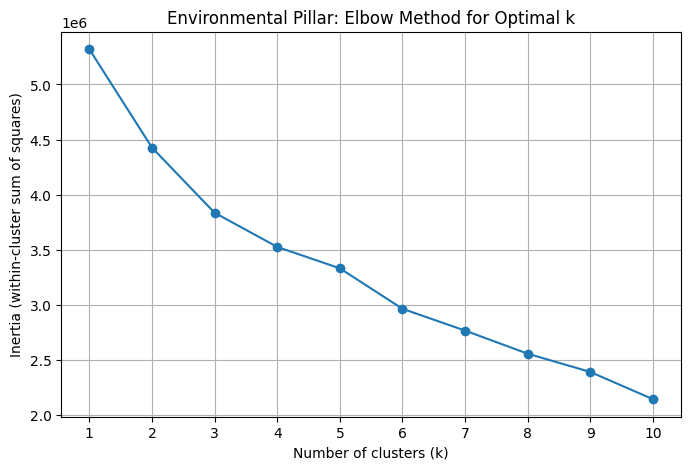

In [8]:
elbow_method(df_env_score, pillar_png='env', pillar_title='Environmental')

╒════════════════════════════════════════════════════════════════════════════════════════════════╤═══════╤═══════╕
│                                                                                                │     0 │     1 │
╞════════════════════════════════════════════════════════════════════════════════════════════════╪═══════╪═══════╡
│ PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)                         │ 46.03 │ 63.91 │
├────────────────────────────────────────────────────────────────────────────────────────────────┼───────┼───────┤
│ Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)                              │ 48.76 │ 69.19 │
├────────────────────────────────────────────────────────────────────────────────────────────────┼───────┼───────┤
│ Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)                     │ 73.92 │ 72.20 │
├───────────────────────────────────────────────────────────────────────────────

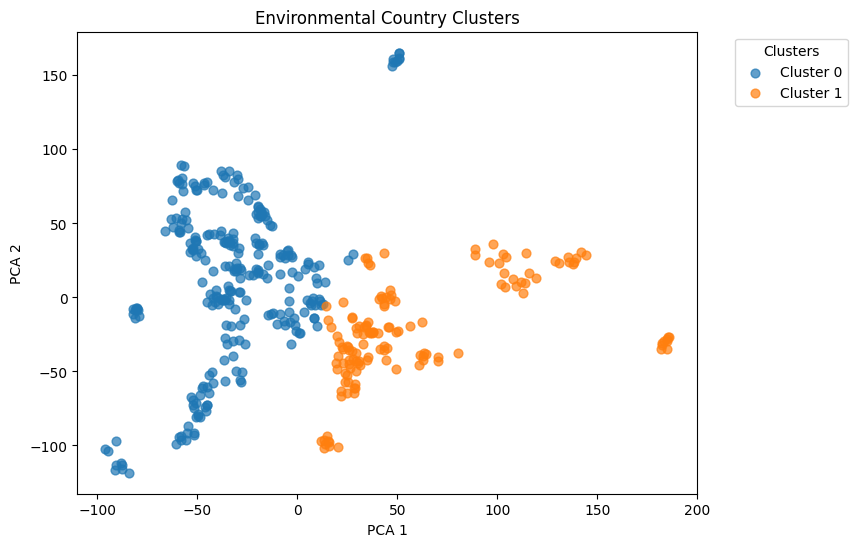

Average silhouette score: 0.180


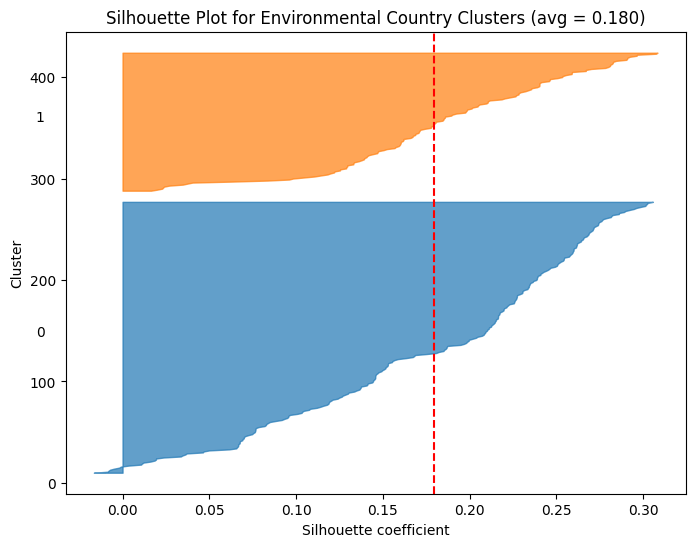

In [9]:
env_clusters = clustering_pca(df_env_score, k=2, pillar_png='env', pillar_title='Environmental')

In [10]:
cluster_summary(env_clusters, pillar_png='env')


=== Cluster 0 ===
Armenia: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Azerbaijan: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Belarus: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Belgium: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Bosnia and Herzegovina: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Bulgaria: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Cyprus: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Czechia: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Denmark: 2012, 2013, 2014, 2015, 2016, 2018
Estonia: 2013, 2014
France: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Germany: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Greece: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Hungary: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Ireland: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Italy: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Kazakhstan: 2012, 2013, 2014, 2015,

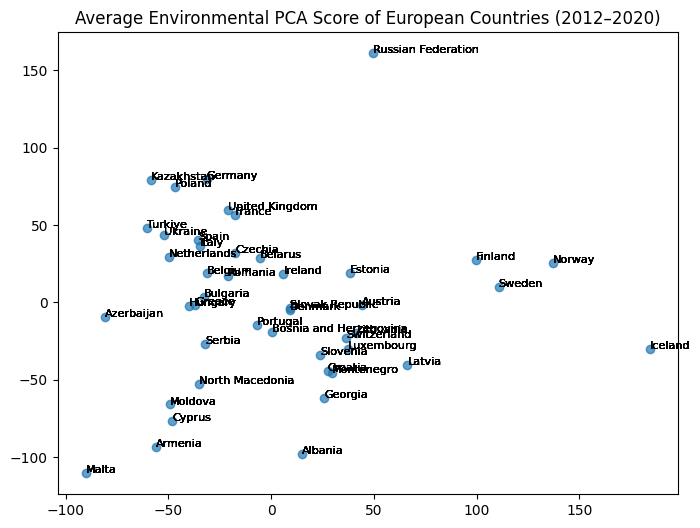

In [11]:
avg_country_pca(df_env_score, pillar_png='env', pillar_title='Environmental')

In [12]:
pca = PCA(n_components=2)
components = pca.fit_transform(df_env_score)

print(pca.explained_variance_ratio_)

[0.24219972 0.20796564]


In [13]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=df_env_pca.columns,
    columns=["PCA1", "PCA2"]
)
loadings.sort_values("PCA1", ascending=False).head(68)

loadings.to_csv(os.path.join(CLUSTER_PCA_EXCEL, 'env_loadings_pca.csv'))

In [14]:
loadings

,PCA1,PCA2
"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",0.236391,0.087175
Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),0.088813,-0.391180
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),-0.071319,-0.169918
Carbon dioxide (CO2) net fluxes from LULUCF - Total excluding non-tropical fires (Mt CO2e),0.027472,0.155364
Methane (CH4) emissions (total) excluding LULUCF (Mt CO2e),0.097619,-0.359303
Nitrous oxide (N2O) emissions (total) excluding LULUCF (Mt CO2e),0.087240,-0.425834
Total greenhouse gas emissions excluding LULUCF (Mt CO2e),0.086019,-0.379485
Total greenhouse gas emissions per capita excluding LULUCF (t CO2e/capita),-0.095060,-0.201229
Electricity production from coal sources (% of total),0.133838,-0.162989
"Energy imports, net (% of energy use)",0.154900,0.143645


In [15]:
df_env_pca.describe(include="all").round(2).T

,count,mean,std,min,25%,50%,75%,max
"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",405.0,-0.00,1.00,-2.49,-0.65,-0.08,0.71,2.30
Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),405.0,0.04,0.99,-2.47,-0.55,0.07,0.82,2.03
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),405.0,0.03,0.99,-4.21,-0.47,0.26,0.68,1.56
Carbon dioxide (CO2) net fluxes from LULUCF - Total excluding non-tropical fires (Mt CO2e),405.0,-0.00,1.00,-2.41,-0.55,0.18,0.73,2.52
Methane (CH4) emissions (total) excluding LULUCF (Mt CO2e),405.0,0.03,0.99,-2.88,-0.52,0.12,0.79,1.84
Nitrous oxide (N2O) emissions (total) excluding LULUCF (Mt CO2e),405.0,0.04,1.00,-2.42,-0.61,0.18,0.93,1.57
Total greenhouse gas emissions excluding LULUCF (Mt CO2e),405.0,0.04,0.99,-2.49,-0.51,0.05,0.84,2.14
Total greenhouse gas emissions per capita excluding LULUCF (t CO2e/capita),405.0,0.03,0.99,-3.57,-0.53,0.28,0.71,1.58
Electricity production from coal sources (% of total),405.0,-0.00,1.00,-2.74,-0.60,0.33,0.89,0.89
"Energy imports, net (% of energy use)",405.0,0.08,1.11,-1.07,-0.44,-0.29,-0.11,3.49


## <span style="color:#e0bda8">4.2. Social Pillar </span>

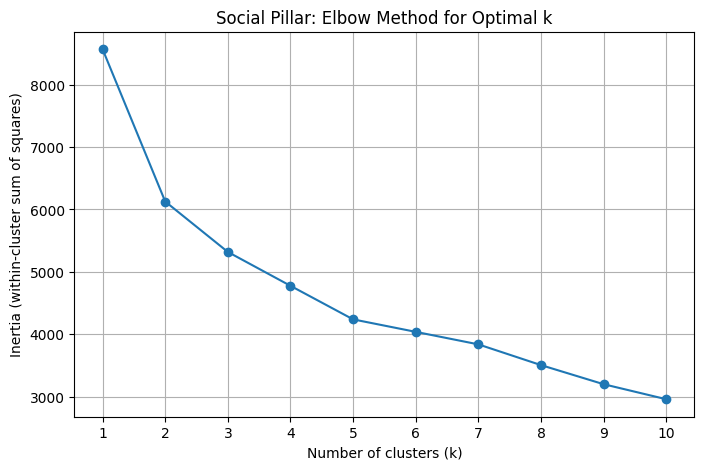

In [16]:
elbow_method(df_soc_pca, pillar_png='soc', pillar_title='Social')

╒═════════════════════════════════════════════════════════════════════════════════════════════════╤═══════╤═══════╕
│                                                                                                 │     0 │     1 │
╞═════════════════════════════════════════════════════════════════════════════════════════════════╪═══════╪═══════╡
│ Access to clean fuels and technologies for cooking  (% of population)                           │  0.38 │ -1.02 │
├─────────────────────────────────────────────────────────────────────────────────────────────────┼───────┼───────┤
│ Access to electricity (% of population)                                                         │  0.15 │ -0.42 │
├─────────────────────────────────────────────────────────────────────────────────────────────────┼───────┼───────┤
│ People using safely managed drinking water services (% of population)                           │  0.46 │ -1.39 │
├───────────────────────────────────────────────────────────────────────

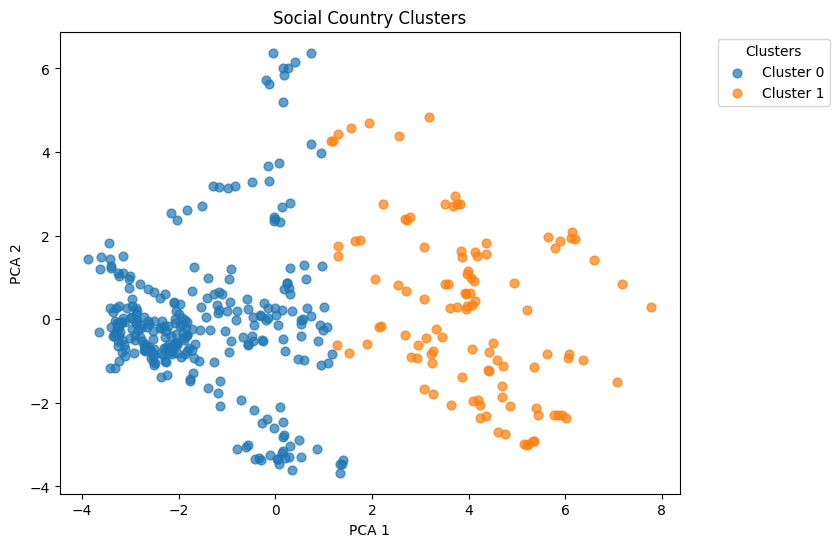

Average silhouette score: 0.342


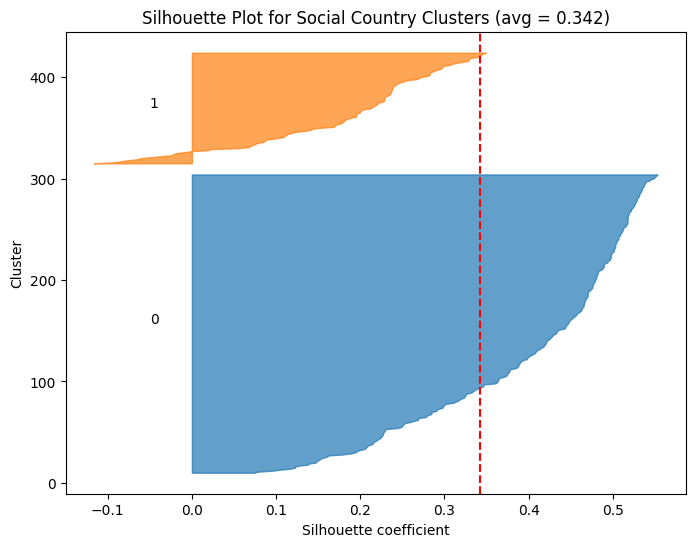

In [17]:
soc_clusters = clustering_pca(df_soc_pca, k=2, pillar_png='soc', pillar_title='Social')

In [18]:
cluster_summary(soc_clusters, pillar_png='soc')


=== Cluster 0 ===
Austria: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Belarus: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Belgium: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Bulgaria: 2020
Croatia: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Cyprus: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Czechia: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Denmark: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Estonia: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Finland: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
France: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Germany: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Greece: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Hungary: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Iceland: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Ireland: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Italy: 2012, 2013, 2014, 2015, 2016, 20

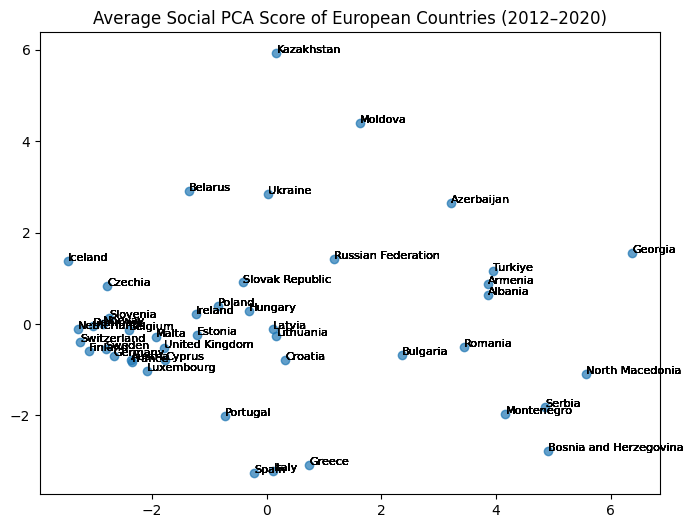

In [19]:
avg_country_pca(df_soc_pca, pillar_png='soc', pillar_title='Social')

In [20]:
pca = PCA(n_components=2)
components = pca.fit_transform(df_soc_score)

print(pca.explained_variance_ratio_)

[0.46960987 0.15816188]


In [21]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=df_soc_pca.columns,
    columns=["PCA1", "PCA2"]
)

loadings.sort_values("PCA1", ascending=False).head(68)

loadings.to_csv(os.path.join(CLUSTER_PCA_EXCEL, 'soc_loadings_pca.csv'))

In [22]:
df_soc_pca.describe(include="all").round(2).T

,count,mean,std,min,25%,50%,75%,max
Access to clean fuels and technologies for cooking (% of population),405.0,0.00,0.99,-4.60,0.19,0.41,0.41,0.41
Access to electricity (% of population),405.0,0.00,1.00,-7.70,0.25,0.25,0.25,0.25
People using safely managed drinking water services (% of population),405.0,-0.05,1.03,-2.61,-0.68,0.40,0.76,0.84
People using safely managed sanitation services (% of population),405.0,-0.02,0.98,-2.80,-0.41,0.16,0.65,1.05
"Fertility rate, total (births per woman)",405.0,0.00,1.00,-2.04,-0.70,-0.13,0.52,4.70
"Life expectancy at birth, total (years)",405.0,0.00,1.00,-2.19,-0.81,-0.00,0.87,1.49
Population ages 65 and above (% of total population),405.0,0.00,1.00,-2.84,-0.64,0.29,0.70,1.77
"Government expenditure on education, total (% of government expenditure)",405.0,-0.04,1.00,-3.65,-0.78,-0.23,0.55,3.57
"School enrollment, primary (% gross)",405.0,0.00,1.00,-3.70,-0.43,-0.03,0.35,4.73
"Labor force participation rate, total (% of total population ages 15-64) (modeled ILO estimate)",405.0,0.00,1.00,-2.74,-0.73,0.06,0.68,2.60


## <span style="color:#e0bda8">4.3. Governance Pillar </span>

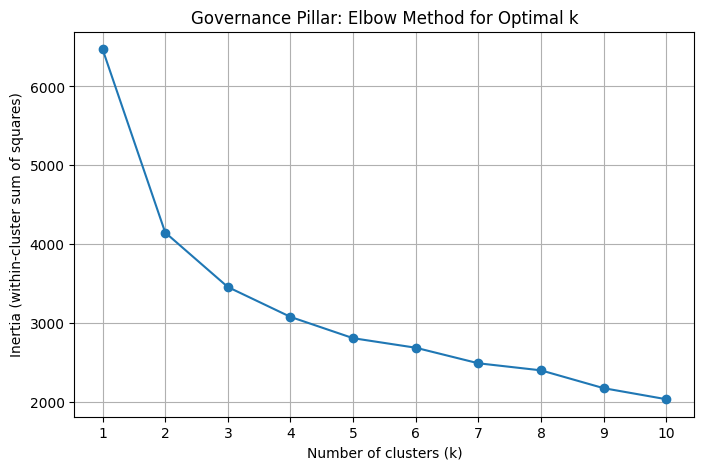

In [23]:
elbow_method(df_gov_pca,pillar_png='gov', pillar_title='Governance')

╒═══════════════════════════════════════════════════════════════════════════════════╤═══════╤═══════╕
│                                                                                   │     0 │     1 │
╞═══════════════════════════════════════════════════════════════════════════════════╪═══════╪═══════╡
│ GDP (annual % growth)                                                             │ -0.06 │  0.05 │
├───────────────────────────────────────────────────────────────────────────────────┼───────┼───────┤
│ Individuals using the Internet (% of population)                                  │  0.71 │ -0.60 │
├───────────────────────────────────────────────────────────────────────────────────┼───────┼───────┤
│ Proportion of seats held by women in national parliaments (%)                     │  0.70 │ -0.59 │
├───────────────────────────────────────────────────────────────────────────────────┼───────┼───────┤
│ Ratio of female to male labor force participation rate (%) (modeled ILO estimate

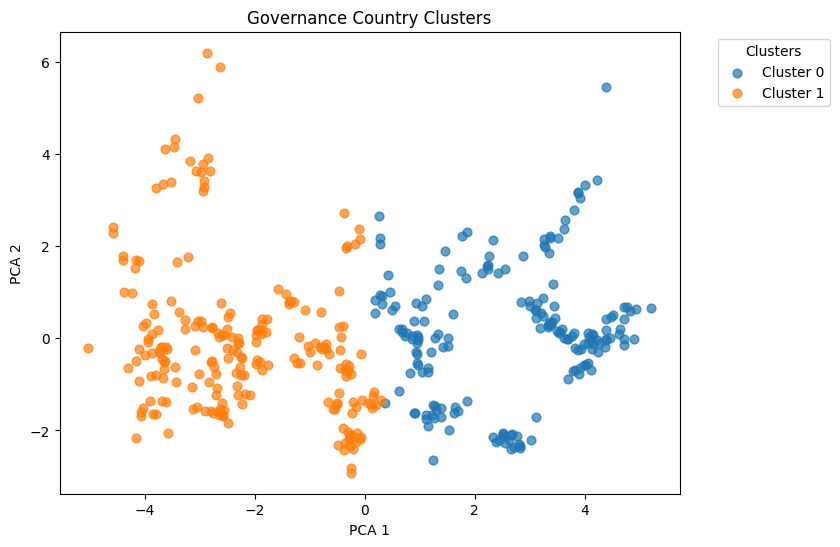

Average silhouette score: 0.308


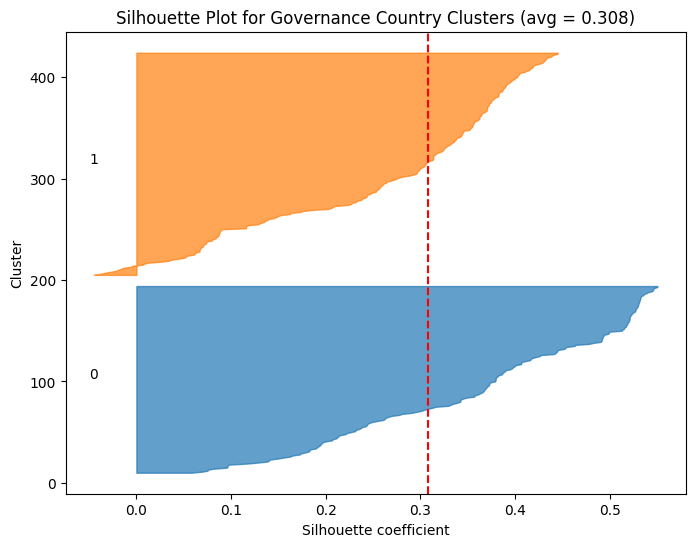

In [24]:
gov_clusters = clustering_pca(df_gov_pca, k=2, pillar_png='gov', pillar_title='Governance')

In [25]:
cluster_summary(gov_clusters, pillar_png='gov')


=== Cluster 0 ===
Austria: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Belgium: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Czechia: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Denmark: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Estonia: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Finland: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
France: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Germany: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Iceland: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Ireland: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Italy: 2018, 2019, 2020
Lithuania: 2019, 2020
Luxembourg: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Netherlands: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Norway: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Poland: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020
Portugal: 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020


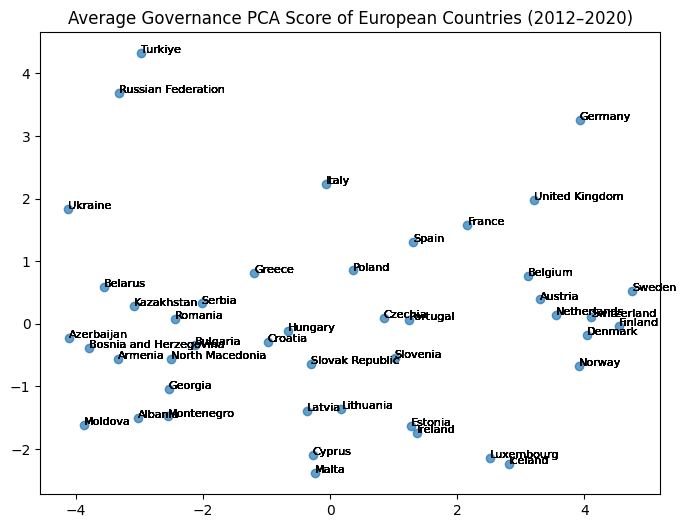

In [26]:
avg_country_pca(df_gov_pca, pillar_png='gov', pillar_title='Governance')

In [27]:
pca = PCA(n_components=2)
components = pca.fit_transform(df_gov_pca)

print(pca.explained_variance_ratio_)

[0.4792129  0.14731409]


In [28]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=df_gov_pca.columns,
    columns=["PCA1", "PCA2"]
)

loadings.sort_values("PCA1", ascending=False).head(68)


loadings.to_csv(os.path.join(CLUSTER_PCA_EXCEL, 'gov_loadings_pca.csv'))

In [29]:
df_gov_pca.describe(include="all").round(2).T

,count,mean,std,min,25%,50%,75%,max
GDP (annual % growth),405.0,0.00,1.00,-4.70,-0.34,0.11,0.51,6.32
Individuals using the Internet (% of population),405.0,-0.00,1.00,-2.93,-0.57,0.12,0.78,1.67
Proportion of seats held by women in national parliaments (%),405.0,-0.00,1.00,-1.82,-0.80,-0.13,0.84,2.16
Ratio of female to male labor force participation rate (%) (modeled ILO estimate),405.0,-0.00,1.00,-4.20,-0.46,0.19,0.52,2.45
"School enrollment, primary and secondary (gross), gender parity index (GPI)",405.0,0.00,0.99,-4.71,-0.34,0.23,0.66,1.06
Government Effectiveness: Estimate,405.0,0.00,1.00,-2.28,-0.92,0.12,0.89,1.87
Regulatory Quality: Estimate,405.0,0.00,1.00,-2.74,-0.76,0.12,0.86,1.67
Economic and Social Rights Performance Score,405.0,0.00,1.00,-3.17,-0.15,0.36,0.65,0.89
Voice and Accountability: Estimate,405.0,0.00,1.00,-2.60,-0.65,0.37,0.80,1.28
"Patent applications, residents",405.0,-0.00,1.00,-2.27,-0.70,0.11,0.66,2.16
